#Trabajo práctico N 1
## Fundamentos de ciencia de datos
#### Integrantes: Agustín Alsop y Rocio Hachen

# **1. Introducción**
Este colab es un anexo al informe adjuntado tp_alsop_hacen.pdf. Acá se detallarán las distintas implementaciones y códigos en Python que se utilizaron a lo largo del analisis para obtener los resultados presentados.

Por motivos de espacio No se pudo adjuntar los data sets utilizados pero se podra encontrar en el siguiente drive:
https://drive.google.com/drive/folders/1JSXQIMRoecWbnfYYyyVY0d_deCt7irXA?usp=sharing



# **2. Base de datos**


## 2.1. Importacion de librerias
Importamos todas las librerias a utilizar

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd

## 2.2. Carga y Limpieza

In [2]:
#Descargamos el dataset
!gdown 18WSLLr18ppvly0fq4zU-Xd9UNAJT7UdV #dataset
!gdown 15O2wUuLwl9pIi2Kg_AGvtlcNCp_1Y3MT #shapefile

!unzip /content/ne_10m_admin_1_states_provinces.zip

Downloading...
From (original): https://drive.google.com/uc?id=18WSLLr18ppvly0fq4zU-Xd9UNAJT7UdV
From (redirected): https://drive.google.com/uc?id=18WSLLr18ppvly0fq4zU-Xd9UNAJT7UdV&confirm=t&uuid=14b02dfc-fdf8-468c-9035-a967966197e9
To: /content/Base Alumnos_AprenderSec_2022.csv
100% 238M/238M [00:02<00:00, 91.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=15O2wUuLwl9pIi2Kg_AGvtlcNCp_1Y3MT
To: /content/ne_10m_admin_1_states_provinces.zip
100% 14.9M/14.9M [00:00<00:00, 64.2MB/s]
Archive:  /content/ne_10m_admin_1_states_provinces.zip
  inflating: ne_10m_admin_1_states_provinces.README.html  
 extracting: ne_10m_admin_1_states_provinces.VERSION.txt  
 extracting: ne_10m_admin_1_states_provinces.cpg  
  inflating: ne_10m_admin_1_states_provinces.dbf  
  inflating: ne_10m_admin_1_states_provinces.prj  
  inflating: ne_10m_admin_1_states_provinces.shp  
  inflating: ne_10m_admin_1_states_provinces.shx  


In [3]:
raw_datos_csv = '/content/Base Alumnos_AprenderSec_2022.csv'
datos_shapefile = '/content/ne_10m_admin_1_states_provinces.shp'

In [4]:
#Para visualizar unas Series en su totalidad, más adelante modificamos estos parámetros. Para asegurarnos que no se imprima el DF en su totalidad, los reiniciamos al comienzo.
pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')

In [5]:
"""Lectura de datos CSV"""
datos = pd.read_csv(raw_datos_csv, sep=';',decimal=',',na_values=' ')
#Al trabajar con el archivo, observamos que hay muchos datos vacíos que han sido marcados con un espacio, así que los asignamos como Naan al leer el archivo.
datos.head()

,jurisdiccion,ID1,idseccion,idalumno,sector,ambito,ap01,ap02,ap03,ap04,...,mpuntaje,NSE_puntaje,NSE_nivel,edadA_junio2022,migracion,sobreedad,Nivel_Ed_Madre,Nivel_Ed_Padre,Nivel_Ed_Persona_Resp,region
0,90,36008003600800,1,655437,1,2,12.0,2.0,2.0,1.0,...,437.40161,-0.372449,2.0,19.0,-9.0,3.0,2.0,2.0,NaN,NOA
1,90,36008003600800,1,655438,1,2,1.0,5.0,2.0,1.0,...,NaN,-0.716539,1.0,17.0,2.0,1.0,2.0,5.0,NaN,NOA
2,90,36008003600800,1,655439,1,2,1.0,5.0,2.0,1.0,...,383.40466,NaN,NaN,17.0,2.0,1.0,4.0,NaN,NaN,NOA
3,90,36008003600800,1,655440,1,2,11.0,2.0,1.0,1.0,...,401.40503,0.122361,2.0,19.0,-9.0,3.0,2.0,NaN,NaN,NOA
4,90,36008003600800,1,655441,1,2,6.0,3.0,1.0,1.0,...,NaN,-0.654602,1.0,19.0,-9.0,3.0,1.0,NaN,NaN,NOA


### Tipos de datos


In [6]:
# Transformamos a las columnas que comienzan con "ap" a tipo object, ya que si bien sus valores son numéricos, en realidad son columnas
# que representan variables cualitativas
columnas_ap = [col for col in datos.columns if col.startswith('ap')]
datos[columnas_ap] = datos[columnas_ap].astype(object)

In [7]:
""" Armamos una tabla para observar los datos de las columnas"""
tipos = datos.dtypes
tipo_unicos = tipos.unique()

resumen_tipos = []

for dtype in tipo_unicos:
    columnas_tipo = tipos[tipos == dtype].index.tolist()
    num_columna = len(columnas_tipo)
    resumen_tipos.append({'Type': dtype, 'Columnas': columnas_tipo, 'NumColumnas': num_columna})

resumen_tipos = pd.DataFrame(resumen_tipos)

resumen_tipos

,Type,Columnas,NumColumnas
0,int64,"[jurisdiccion, ID1, idseccion, idalumno, secto...",6
1,object,"[ap01, ap02, ap03, ap04, ap05, ap06, ap07, ap0...",210
2,float64,"[ponder, lpondera, mpondera, ldesemp, mdesemp,...",15


Los tipos de datos son correctos. Región es la única columna que contiene strings, por lo que será de tipo `object`. Las columnas `apxx` podrían ser `int64`, pero al contener valores `Naan`, Pandas les asigna el tipo `float64`. Esto podría corregirse, pero consideramos que no afecta al uso y análisis del dataset, así que lo dejamos así.

### Valores `NaaN`

In [8]:
pd.set_option('display.max_rows',None)
val_naan = datos.isna().sum()
val_naan
#Estos Naan son "validos", Hay algunos alumnos que no tienen su NSE calculado, pero tienen sus resultados de examen, hay varios que no respondieron las preguntas, pero sí hicieron el examen. Después podemos analziar qué hacemos

jurisdiccion                  0
ID1                           0
idseccion                     0
idalumno                      0
sector                        0
ambito                        0
ap01                       9069
ap02                       9069
ap03                       9069
ap04                       9069
ap05                       9069
ap06                       9069
ap07                       9069
ap08                       9069
ap09a                      9069
ap09b                      9069
ap09c                      9069
ap09d                      9069
ap09e                      9069
ap09f                      9069
ap09g                      9069
ap09h                      9069
ap09i                      9069
ap09j                      9069
ap09k                      9069
ap09l                      9069
ap09m                      9069
ap10                       9069
ap11                       9069
ap12a                      9069
ap12b                      9069
ap12c   

In [9]:
pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')

In [10]:
print(f'Hay {val_naan.sum()} valores Naan')
pd.reset_option('display.max_rows')

Hay 2624267 valores Naan


Existen muchos valores `NaaN`, y estos varían según cada columna. Podemos observar que las columnas `apxx` tienen una cantidad de valores `NaaN` consistente: **9069**. Esto es así ya que las columnas apxx son aquellas que corresponden a las preguntas de interés, y hubo varias escuelas que no incluyeron estas preguntas en el examen. \\
También observamos que algunos estudiantes no realizaron el examen de lengua, pero sí el de matemática, y visceversa. \\
Otros valores NaaN también son lógicos. Por ejemplo, `Nivel_Ed_Persona_Resp` tiene 387058 valores `NaaN`, pero esto resulta lógico al considerar que no son muchos los niños que tienen un guardián en vez de padre o madre.

### Filas duplicadas

In [11]:
print(f'Hay {datos.duplicated().sum()} filas duplicadas')

Hay 0 filas duplicadas


### Errores en las strings
Verificamos si existen errores en las strings.

In [12]:
# Chequeamos el contenido de Región, nuestra única columna de tipo object
region_u = datos['region'].unique()
print(f'La columna región contiene los siguientes valores: {region_u}')

La columna región contiene los siguientes valores: ['NOA' 'CENTRO' 'CUYO' 'SUR' 'NEA']


### Index
Analizamos si la columna "ID1" puede ser utilizada como index

In [13]:
print(f'La columna "ID1" es válida como Index: {len(datos["ID1"]) == len(datos["ID1"].unique())}')

La columna "ID1" es válida como Index: False


# **3. Análisis**

## 3.1 Rango de datos

In [14]:
""" Creamos un describe para cada tipo de dato"""
print('-----------------------------------------------------\n')
for dtype in resumen_tipos['Type']:
    tipo_columna = resumen_tipos.loc[resumen_tipos['Type'] == dtype, 'Columnas'].iloc[0]
    df_tipo = datos[tipo_columna]
    describe = df_tipo.describe()
    print(f"Descripción de columnas tipo '{dtype}':\n{describe}\n")
    print('-----------------------------------------------------\n')

-----------------------------------------------------

Descripción de columnas tipo 'int64':
        jurisdiccion           ID1      idseccion       idalumno  \
count  403468.000000  4.034680e+05  403468.000000  403468.000000   
mean       30.581042  4.128434e+14       2.056733  350446.546014   
std        30.037316  2.387983e+14       1.514718  188468.224331   
min         2.000000  3.600800e+13       1.000000       1.000000   
25%         6.000000  2.053200e+14       1.000000  201723.750000   
50%        14.000000  3.584000e+14       2.000000  354909.500000   
75%        54.000000  5.821200e+14       3.000000  506959.250000   
max        94.000000  9.996009e+14      19.000000  669828.000000   

              sector         ambito  
count  403468.000000  403468.000000  
mean        1.381728       1.919347  
std         0.485811       0.272302  
min         1.000000       1.000000  
25%         1.000000       2.000000  
50%         1.000000       2.000000  
75%         2.000000       2

## 3.2 Análisis general país

<ipython-input-15-c1a206d2c973>:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  datos['provincia'] = datos['jurisdiccion'].map(provincia_mapping)


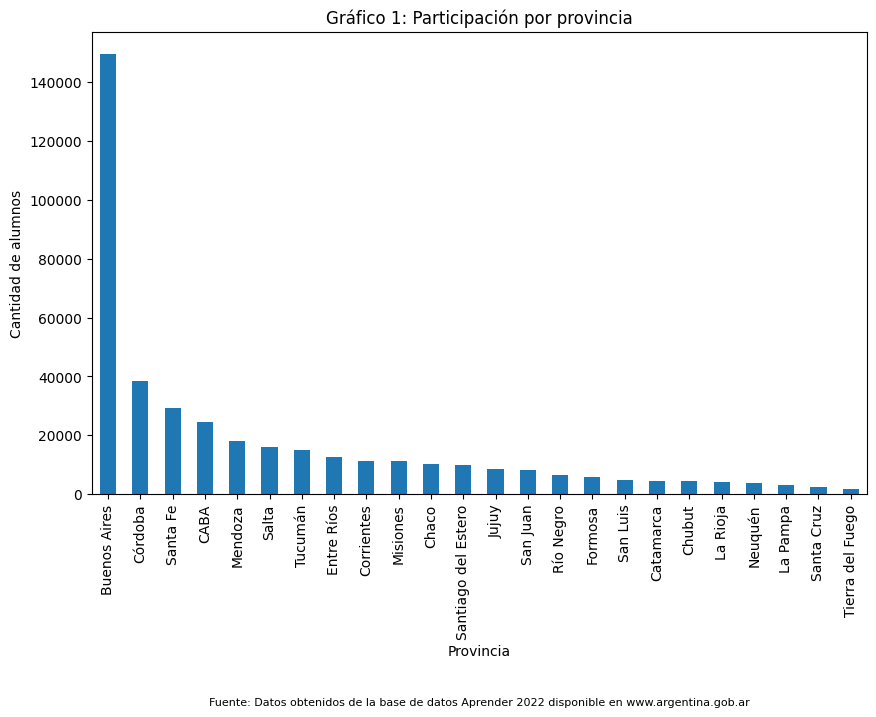

In [15]:
# Mapeamos los numeros a las provincias
provincia_mapping = {
    2: 'CABA',
    6: 'Buenos Aires',
    10: 'Catamarca',
    14: 'Córdoba',
    18: 'Corrientes',
    22: 'Chaco',
    26: 'Chubut',
    30: 'Entre Ríos',
    34: 'Formosa',
    38: 'Jujuy',
    42: 'La Pampa',
    46: 'La Rioja',
    50: 'Mendoza',
    54: 'Misiones',
    58: 'Neuquén',
    62: 'Río Negro',
    66: 'Salta',
    70: 'San Juan',
    74: 'San Luis',
    78: 'Santa Cruz',
    82: 'Santa Fe',
    86: 'Santiago del Estero',
    90: 'Tucumán',
    94: 'Tierra del Fuego'
}

datos['provincia'] = datos['jurisdiccion'].map(provincia_mapping)

plt.figure(figsize=(12, 6))
section_distribution = datos['provincia'].value_counts()
section_distribution.plot(kind='bar', figsize=(10, 6),grid=False)
plt.xlabel('Provincia')
plt.ylabel('Cantidad de alumnos')
plt.title('Gráfico 1: Participación por provincia')
plt.text(0.5, -0.45, 'Fuente: Datos obtenidos de la base de datos Aprender 2022 disponible en www.argentina.gob.ar', ha='center', va='center', transform=plt.gca().transAxes, fontsize=8)
plt.show()


In [16]:
datos['provincia'].value_counts()

provincia
Buenos Aires           149500
Córdoba                 38282
Santa Fe                29247
CABA                    24445
Mendoza                 18019
Salta                   15938
Tucumán                 14968
Entre Ríos              12455
Corrientes              11390
Misiones                11118
Chaco                   10345
Santiago del Estero      9854
Jujuy                    8505
San Juan                 8025
Río Negro                6502
Formosa                  5881
San Luis                 4752
Catamarca                4446
Chubut                   4372
La Rioja                 4242
Neuquén                  3887
La Pampa                 3109
Santa Cruz               2382
Tierra del Fuego         1804
Name: count, dtype: int64

## 3.3 Análisis regiones

In [17]:
colors = {'CENTRO': 'tab:orange',
           'NOA': 'tab:blue',
           'CUYO': 'tab:green',
           'NEA': 'tab:purple',
           'SUR': 'tab:red'}

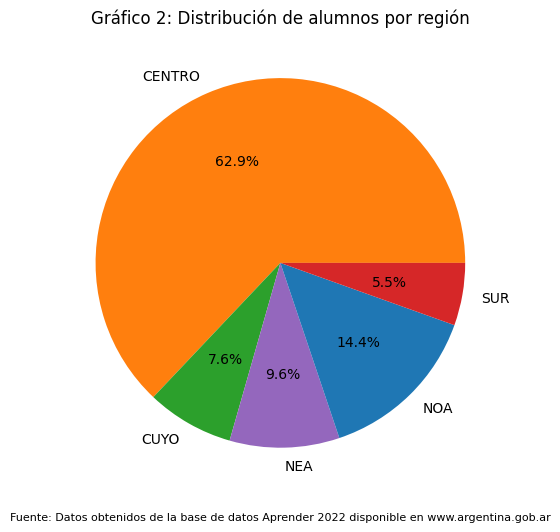

region
CENTRO    253929
CUYO       30796
NEA        38734
NOA        57953
SUR        22056
dtype: int64

In [18]:
plt.figure(figsize=(12, 6))
regiones = datos.groupby('region').size()
plt.pie(regiones, labels=regiones.index, autopct='%1.1f%%',colors=[colors[key] for key in regiones.index])
plt.title('Gráfico 2: Distribución de alumnos por región')
plt.text(0.5, -0.05, 'Fuente: Datos obtenidos de la base de datos Aprender 2022 disponible en www.argentina.gob.ar', ha='center', va='center', transform=plt.gca().transAxes, fontsize=8)
plt.show()
regiones

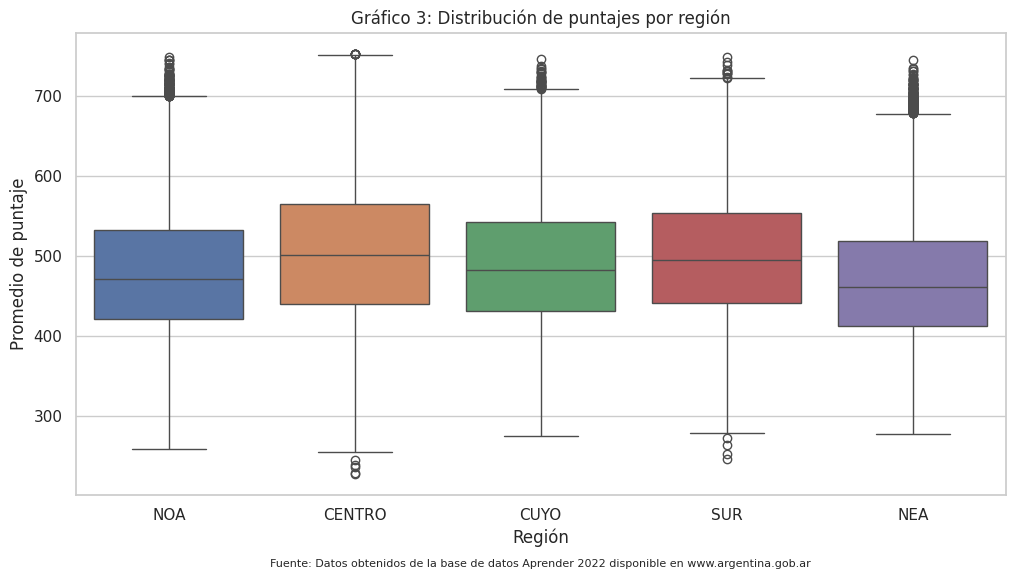

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
CENTRO,239582.0,503.854114,83.448784,227.630030,440.442441,500.650728,564.846829,752.79907
CUYO,29647.0,488.087129,76.819315,274.982775,430.634552,482.585020,541.866408,746.76227
NEA,36367.0,468.922372,74.945825,276.953995,412.549035,460.734420,518.603668,745.48517
NOA,54967.0,479.515405,77.864047,258.385300,420.805955,471.450105,532.222483,749.09610
SUR,20310.0,498.914242,78.241094,245.556060,441.196626,495.120775,553.572961,749.09610


In [19]:
datos2 = datos.copy()
datos2['prom_puntaje'] = (datos2['lpuntaje'] + datos2['mpuntaje']) / 2
datos = datos2

datos_sna = datos.dropna(subset=['mpuntaje', 'lpuntaje']).copy()
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.boxplot(x='region', y='prom_puntaje', hue='region', data=datos_sna)
plt.title('Gráfico 3: Distribución de puntajes por región')
plt.text(0.5, -0.15, 'Fuente: Datos obtenidos de la base de datos Aprender 2022 disponible en www.argentina.gob.ar', ha='center', va='center', transform=plt.gca().transAxes, fontsize=8)
plt.xlabel('Región')
plt.ylabel('Promedio de puntaje')
plt.show()

datos_sna.groupby('region')['prom_puntaje'].describe()

### Gráfico georeferenciado

In [20]:
# Shapefile mundial filtrado para incluir solo los resultados de argentina
gdf = gpd.read_file(datos_shapefile)
argentina = gdf[gdf['iso_a2'] == 'AR'][['name', 'geometry']]

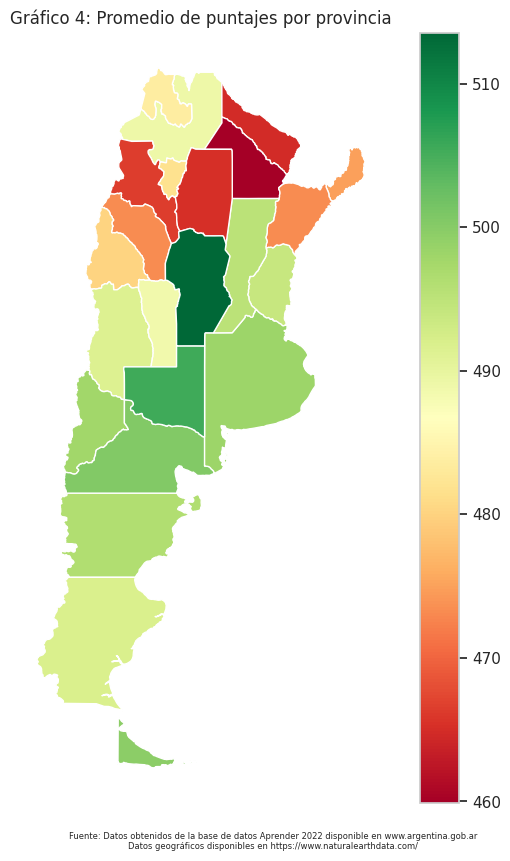

In [21]:
# Calculo el promedio de puntajes por provincia
prom_prov = datos.groupby('provincia')['prom_puntaje'].mean()

# Uno el promedio de puntajes con el GeoDataFrame 'provinces'
provincias_mapa_prom = argentina.merge(prom_prov, left_on='name', right_on='provincia')

# Grafico el mapa
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
provincias_mapa_prom.plot(column='prom_puntaje', cmap='RdYlGn', legend=True, ax=ax)
plt.title('Gráfico 4: Promedio de puntajes por provincia')
plt.text(0.7,-0.05, 'Fuente: Datos obtenidos de la base de datos Aprender 2022 disponible en www.argentina.gob.ar\nDatos geográficos disponibles en https://www.naturalearthdata.com/', ha='center', va='center', transform=plt.gca().transAxes, fontsize=6)
plt.axis('off')
plt.show()



In [22]:
prom_prov # Promedio de puntaje de cada provincia
#Córdoba destaca con la mejor puntuación promedio de 513,54 puntos.

provincia
Buenos Aires           498.200113
CABA                   538.043028
Catamarca              466.588520
Chaco                  459.907464
Chubut                 496.163337
Corrientes             473.193247
Córdoba                513.541309
Entre Ríos             494.043013
Formosa                464.783164
Jujuy                  483.786581
La Pampa               505.524471
La Rioja               473.130958
Mendoza                491.535976
Misiones               474.815868
Neuquén                497.792175
Río Negro              500.489293
Salta                  489.124789
San Juan               480.153961
San Luis               488.629257
Santa Cruz             491.824440
Santa Fe               495.232766
Santiago del Estero    465.281939
Tierra del Fuego       499.674089
Tucumán                481.827298
Name: prom_puntaje, dtype: float64

Participaron todas las provincias y la Ciudad Autónoma de Buenos Aires. En este estudio, vamos a concentrarnos en los resultados de la provincia de Santa Fe

## 3.4 Análisis Santa Fe

In [23]:
datos_santafe = datos[datos['provincia']== 'Santa Fe'].copy()
datos_santafe

,jurisdiccion,ID1,idseccion,idalumno,sector,ambito,ap01,ap02,ap03,ap04,...,NSE_nivel,edadA_junio2022,migracion,sobreedad,Nivel_Ed_Madre,Nivel_Ed_Padre,Nivel_Ed_Persona_Resp,region,provincia,prom_puntaje
504,82,100170051673231,1,599878,1,2,5.0,5.0,1.0,1.0,...,2.0,17.0,2.0,1.0,NaN,NaN,NaN,CENTRO,Santa Fe,444.623200
505,82,100170051673231,1,599879,1,2,11.0,4.0,1.0,1.0,...,1.0,17.0,2.0,1.0,NaN,NaN,5.0,CENTRO,Santa Fe,418.963625
506,82,100170051673231,1,599880,1,2,7.0,4.0,1.0,1.0,...,2.0,17.0,2.0,1.0,5.0,2.0,NaN,CENTRO,Santa Fe,359.566130
507,82,100170051673231,1,599881,1,2,1.0,4.0,1.0,1.0,...,3.0,18.0,2.0,2.0,7.0,5.0,NaN,CENTRO,Santa Fe,378.629900
508,82,100170051673231,1,599884,1,2,1.0,3.0,2.0,1.0,...,1.0,19.0,2.0,3.0,4.0,4.0,1.0,CENTRO,Santa Fe,428.918580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403438,82,999600836400099,2,604096,1,2,11.0,4.0,1.0,1.0,...,3.0,17.0,2.0,1.0,7.0,4.0,NaN,CENTRO,Santa Fe,531.437195
403439,82,999600836400099,2,604097,1,2,9.0,4.0,1.0,1.0,...,2.0,17.0,2.0,1.0,3.0,5.0,NaN,CENTRO,Santa Fe,540.743775
403440,82,999600836400099,2,604098,1,2,8.0,4.0,1.0,1.0,...,3.0,17.0,2.0,1.0,7.0,7.0,NaN,CENTRO,Santa Fe,473.221450
403441,82,999600836400099,2,604099,1,2,11.0,4.0,2.0,1.0,...,2.0,17.0,2.0,1.0,5.0,5.0,NaN,CENTRO,Santa Fe,488.272565


### Análisis descriptivo Santa Fe

In [24]:
# Análisis descriptivo de Santa Fe
registros_totales = len(datos_santafe)
prom_puntaje = datos_santafe['prom_puntaje'].mean()
max_mat = datos_santafe['mpuntaje'].max()
min_mat = datos_santafe['mpuntaje'].min()
max_leng = datos_santafe['lpuntaje'].max()
min_leng = datos_santafe['lpuntaje'].min()

escuelas_publicas = (datos_santafe['sector'] == 1).sum()
escuelas_privadas = (datos_santafe['sector'] == 2).sum()

descr_santafe = {'registros_totales': [registros_totales], 'puntaje_promedio': [prom_puntaje],'max_mat': [max_mat],'min_mat': [min_mat],'max_leng': [max_leng], 'min_leng':[min_leng],'escuelas_publicas' : [escuelas_publicas],'escuelas_privadas' : [escuelas_privadas]}
descr_santafe = pd.DataFrame(data=descr_santafe)
descr_santafe


,registros_totales,puntaje_promedio,max_mat,min_mat,max_leng,min_leng,escuelas_publicas,escuelas_privadas
0,29247,495.232766,691.0733,292.03134,822.41638,182.47527,16732,12515


In [25]:
datos_santafe[['mpuntaje','lpuntaje','prom_puntaje']].describe()

,mpuntaje,lpuntaje,prom_puntaje
count,28020.000000,28304.000000,27631.000000
mean,477.346300,511.927714,495.232766
std,67.594532,113.997897,81.032239
min,292.031340,182.475270,271.444885
25%,427.169803,426.990340,433.478068
50%,469.695910,508.853685,490.525700
75%,522.853102,595.200365,553.866358
max,691.073300,822.416380,752.799070


In [26]:
# Editamos columnas
sector_mapping = {
    1 : 'Estatal',
    2 : 'Privado'
}

NSE_mapping = {
    1 : 'Bajo',
    2 : 'Medio',
    3 : 'Alto'
}
datos_santafe['sector'] = datos_santafe['sector'].map(sector_mapping)
datos_santafe['NSE_nivel'] = datos_santafe['NSE_nivel'].map(NSE_mapping)
datos_santafe['NSE_nivel'] = pd.Categorical(datos_santafe['NSE_nivel'], categories=['Bajo', 'Medio', 'Alto'], ordered=True)

### Matriz de correlación

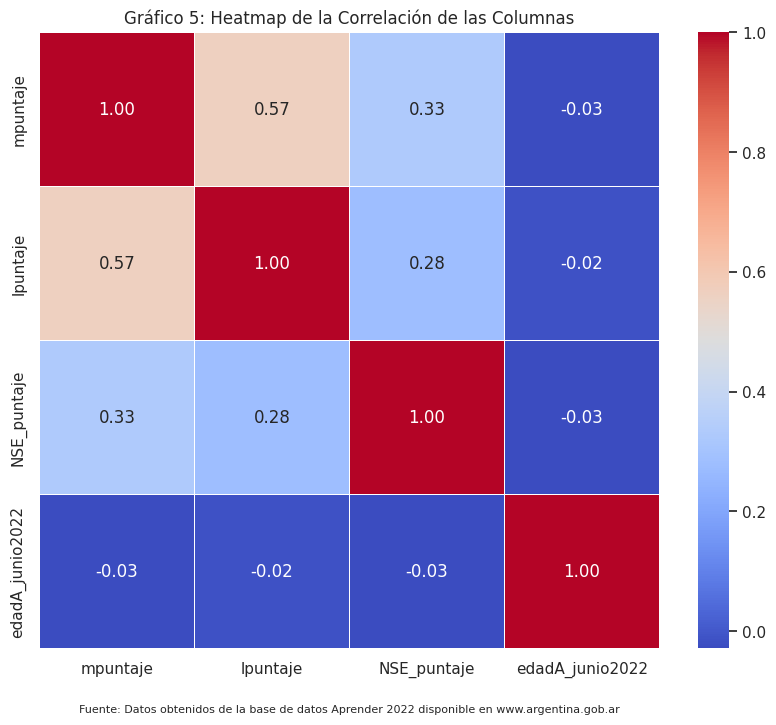

In [27]:
datos3= datos_santafe[['mpuntaje','lpuntaje','NSE_puntaje','edadA_junio2022']]
datos_con_dummies = pd.get_dummies(datos3)
# Calcular la matriz de correlación
correlacion = datos_con_dummies.corr()

# Crear el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Gráfico 5: Heatmap de la Correlación de las Columnas')
plt.text(0.5, -0.1, 'Fuente: Datos obtenidos de la base de datos Aprender 2022 disponible en www.argentina.gob.ar', ha='center', va='center', transform=plt.gca().transAxes, fontsize=8)

plt.show()


## 3.5 (Pregunta 1) Los alumnos que obtuvieron buena calificación en un examen, ¿tienden a tener buena puntuación en la otra materia?

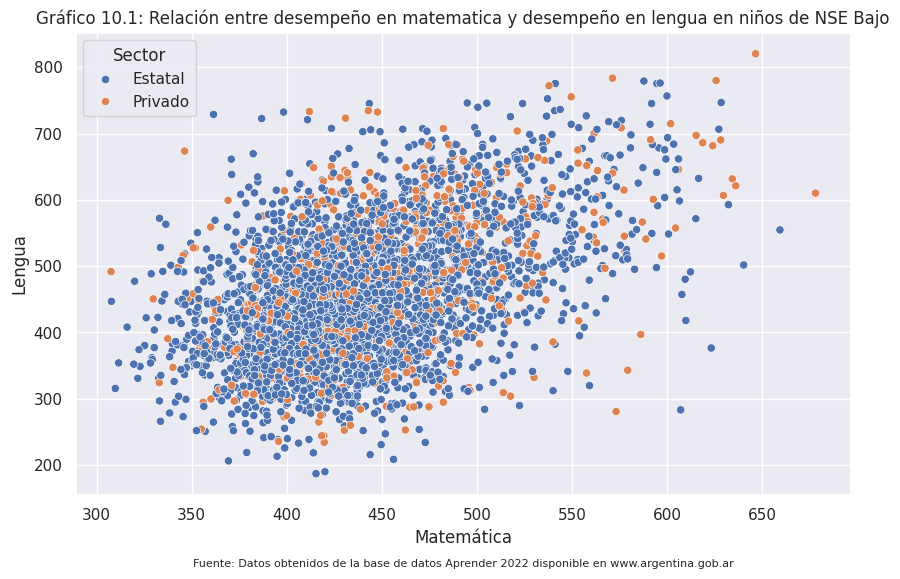

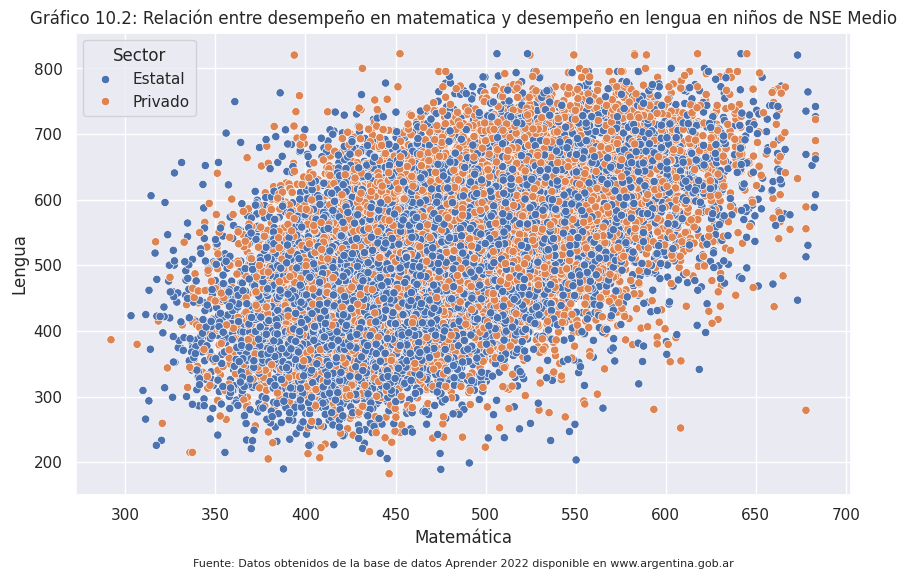

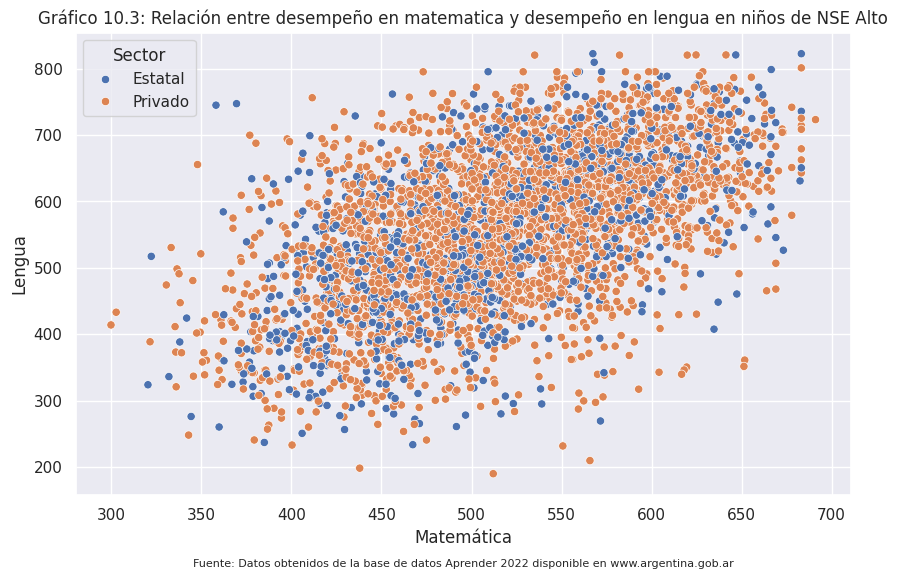

In [28]:
#Scatterplot: Relación entre el puntaje de Lengua y el puntaje de Matemático.
sf_sin_na = datos_santafe.dropna(subset=['lpuntaje','mpuntaje']).copy()
niveles = ['Bajo','Medio','Alto']
for i in range(0,len(niveles)):
  sns.set()
  plt.figure(figsize=(10, 6))
  datos_santafe_filtrado= sf_sin_na[sf_sin_na['NSE_nivel']==niveles[i]]
  sns.scatterplot(x=datos_santafe_filtrado['mpuntaje'], y=datos_santafe_filtrado['lpuntaje'],hue=datos_santafe_filtrado['sector'])
  plt.xlabel('Matemática')
  plt.ylabel('Lengua')
  plt.title(f'Gráfico 10.{i+1}: Relación entre desempeño en matematica y desempeño en lengua en niños de NSE {niveles[i]}')
  plt.text(0.5, -0.15, 'Fuente: Datos obtenidos de la base de datos Aprender 2022 disponible en www.argentina.gob.ar', ha='center', va='center', transform=plt.gca().transAxes, fontsize=8)
  plt.legend(title='Sector')
  i = i+1
  plt.show()



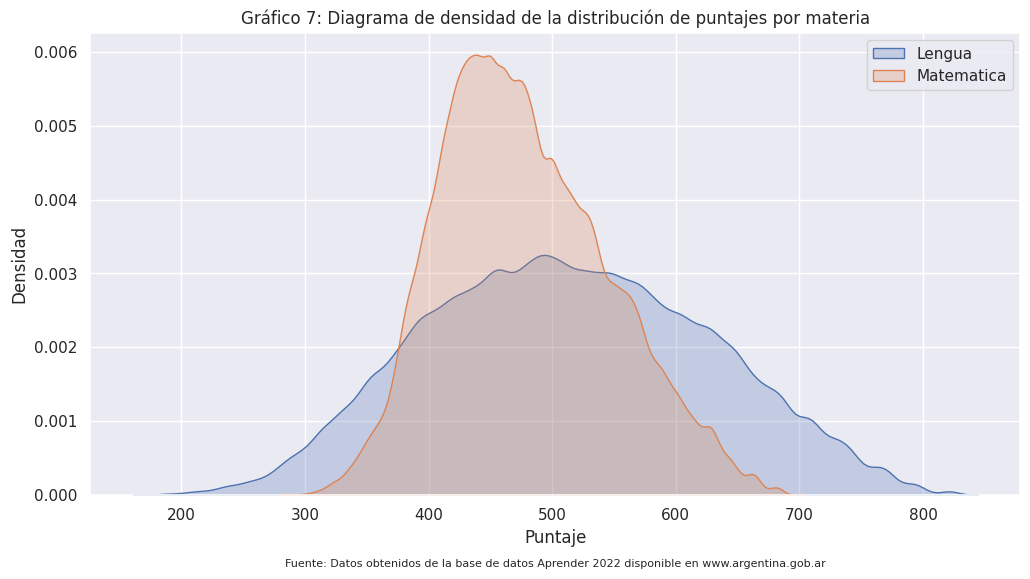

In [29]:
# Diagrama de densidades

bandwidth = 0.5
plt.figure(figsize=(12, 6))
sns.kdeplot(data=sf_sin_na['lpuntaje'], fill=True, label='Lengua', bw_adjust=bandwidth)
sns.kdeplot(data=sf_sin_na['mpuntaje'], fill=True, label='Matematica', bw_adjust=bandwidth)
plt.title('Gráfico 7: Diagrama de densidad de la distribución de puntajes por materia')
plt.text(0.5, -0.15, 'Fuente: Datos obtenidos de la base de datos Aprender 2022 disponible en www.argentina.gob.ar', ha='center', va='center', transform=plt.gca().transAxes, fontsize=8)
plt.xlabel('Puntaje')
plt.ylabel('Densidad')
plt.legend()
plt.show()

Hay una pequeña tendencia a una relación lineal positiva. Además, las variables tienen distribución normal.

In [30]:
#Medida de dispersion
datos_puntaje = datos_santafe[['mpuntaje','lpuntaje']].describe().transpose()
datos_puntaje['RI'] = datos_puntaje['75%'] - datos_puntaje['25%'] #Rango intercuartil
datos_puntaje

,count,mean,std,min,25%,50%,75%,max,RI
mpuntaje,28020.0,477.346300,67.594532,292.03134,427.169803,469.695910,522.853102,691.07330,95.683300
lpuntaje,28304.0,511.927714,113.997897,182.47527,426.990340,508.853685,595.200365,822.41638,168.210025


## 3.6 (Pregunta 2) ¿Se podría decir que el nivel socioeconómico de un niño impactará su posibilidad de un rendimiento escolar exitoso? ¿El sector de gestión escolar influye también?


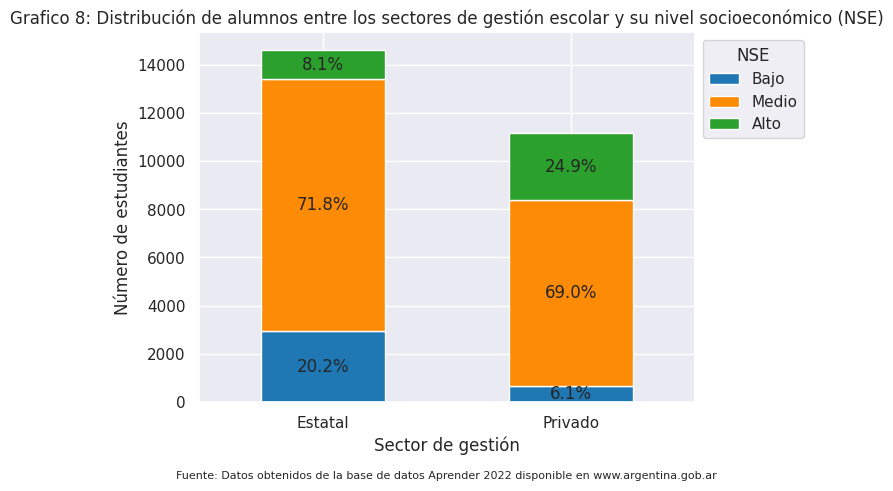

In [31]:
sf_sin_na = datos_santafe.dropna(subset=['sector','NSE_nivel']).copy()
sector_NSE_sf = sf_sin_na.groupby(['sector', 'NSE_nivel']).size().unstack()

NSE_orden = ['Bajo', 'Medio', 'Alto']
sector_NSE_sf = sector_NSE_sf[NSE_orden]

porcentaje = sector_NSE_sf.divide(sector_NSE_sf.sum(axis=1), axis=0) * 100
sns.set(style="darkgrid")
sector_NSE_sf.plot(kind='bar', stacked=True, color=['tab:blue', '#fe8b05', 'tab:green'])
plt.title("Grafico 8: Distribución de alumnos entre los sectores de gestión escolar y su nivel socioeconómico (NSE)")
plt.text(0.5, -0.2, 'Fuente: Datos obtenidos de la base de datos Aprender 2022 disponible en www.argentina.gob.ar', ha='center', va='center', transform=plt.gca().transAxes, fontsize=8)
plt.xlabel('Sector de gestión')
plt.ylabel('Número de estudiantes')
plt.xticks([0, 1], ['Estatal', 'Privado'], rotation=0)
plt.legend(title='NSE', bbox_to_anchor=(1, 1))

for i in range(len(sector_NSE_sf.index)):
    cumulative = 0
    for j in range(len(sector_NSE_sf.columns)):
        cumulative += sector_NSE_sf.iloc[i, j]
        plt.annotate(f'{porcentaje.iloc[i, j]:.1f}%',
                    xy=(i, cumulative - sector_NSE_sf.iloc[i, j] / 2),
                    ha='center', va='center')

plt.show()

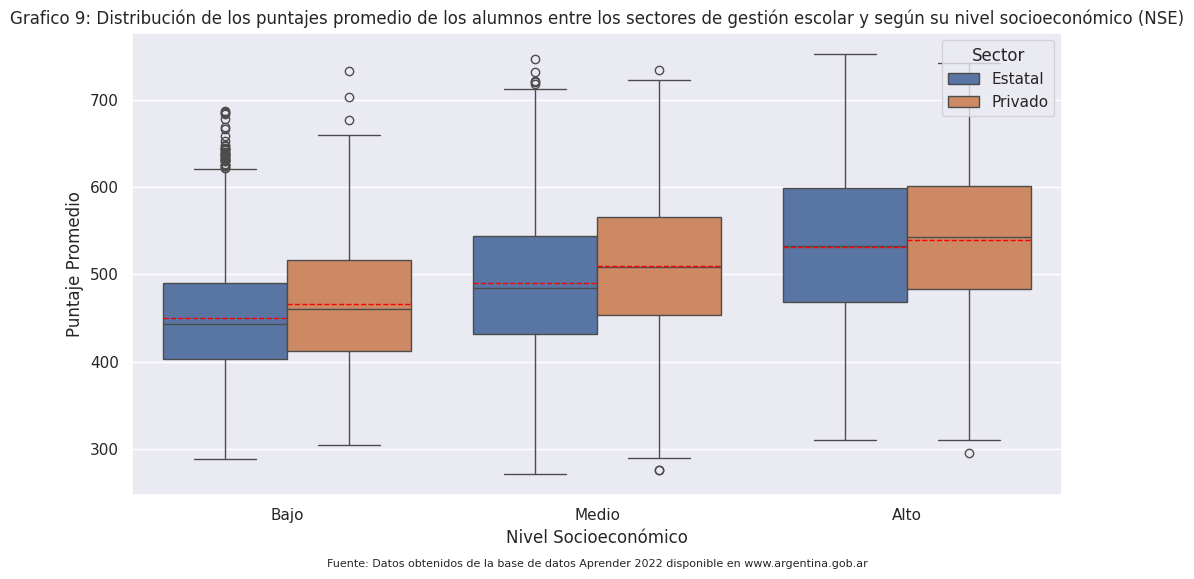

In [32]:
sns.set(style="darkgrid")
plt.figure(figsize=(12, 6))
sns.boxplot(x='NSE_nivel', y='prom_puntaje', hue='sector', data=sf_sin_na, showmeans=True, meanline=True, meanprops={'color': 'red'})
plt.xlabel('Nivel Socioeconómico')
plt.ylabel('Puntaje Promedio')
plt.title("Grafico 9: Distribución de los puntajes promedio de los alumnos entre los sectores de gestión escolar y según su nivel socioeconómico (NSE)")
plt.legend(title='Sector')
plt.text(0.5, -0.15, 'Fuente: Datos obtenidos de la base de datos Aprender 2022 disponible en www.argentina.gob.ar', ha='center', va='center', transform=plt.gca().transAxes, fontsize=8)
plt.show()

## 3.7 (Pregunta 3) ¿Cuál es el impacto negativo de que un niño no tenga internet/celular? ¿Afecta su rendimiento escolar?

In [33]:
def labels_barplot(dataset,ax):
  total = len(dataset)
  for container in ax.containers:
      labels = [f'{(v.get_height() / total) * 100:.1f}% ({int(v.get_height())})' for v in container]
      ax.bar_label(container, labels=labels)

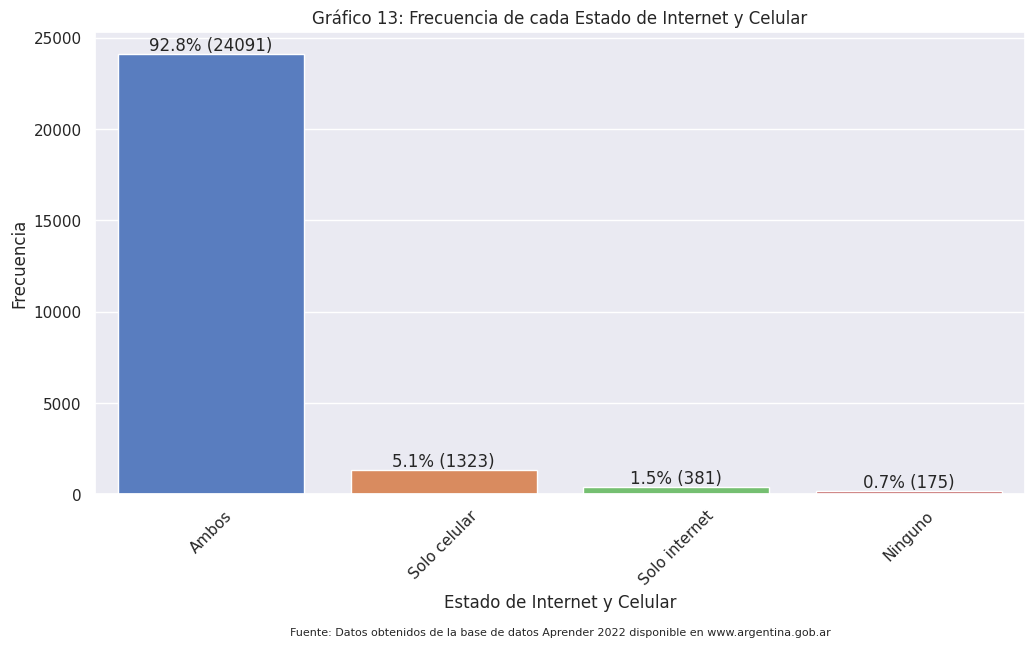

In [34]:
sf_sin_na = datos_santafe.dropna(subset=['mpuntaje','lpuntaje','prom_puntaje','ap12k','ap13']).copy()

datos_internet = sf_sin_na[['mpuntaje','lpuntaje','prom_puntaje','ap12k','ap13']].copy()
datos_internet = datos_internet[((datos_internet['ap12k'].isin([1,2])) & (datos_internet['ap13'].isin([1,2])))]


condiciones = [
    (datos_internet['ap12k'] == 2) & (datos_internet['ap13'] == 2),
    (datos_internet['ap12k'] == 1) & (datos_internet['ap13'] == 2),
    (datos_internet['ap12k'] == 2) & (datos_internet['ap13'] == 1),
    (datos_internet['ap12k'] == 1) & (datos_internet['ap13'] == 1)
]

opciones = ['Ninguno', 'Solo internet', 'Solo celular', 'Ambos']

datos_internet['estado_internet'] = np.select(condiciones, opciones)

# Frecuencia de cada "estado"
estado_counts = datos_internet['estado_internet'].value_counts().reset_index()
estado_counts.columns = ['estado_internet', 'conteo']

# Gráfico de barras con la frecuencia de cada "estado"
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='estado_internet', y='conteo', hue='estado_internet', data=estado_counts, palette='muted')
plt.title('Gráfico 13: Frecuencia de cada Estado de Internet y Celular')
plt.xlabel('Estado de Internet y Celular')
plt.ylabel('Frecuencia')
plt.text(0.5, -0.3, 'Fuente: Datos obtenidos de la base de datos Aprender 2022 disponible en www.argentina.gob.ar', ha='center', va='center', transform=plt.gca().transAxes, fontsize=8)
plt.xticks(rotation=45)

# Añadimos los labels
labels_barplot(datos_internet,ax)

plt.show()


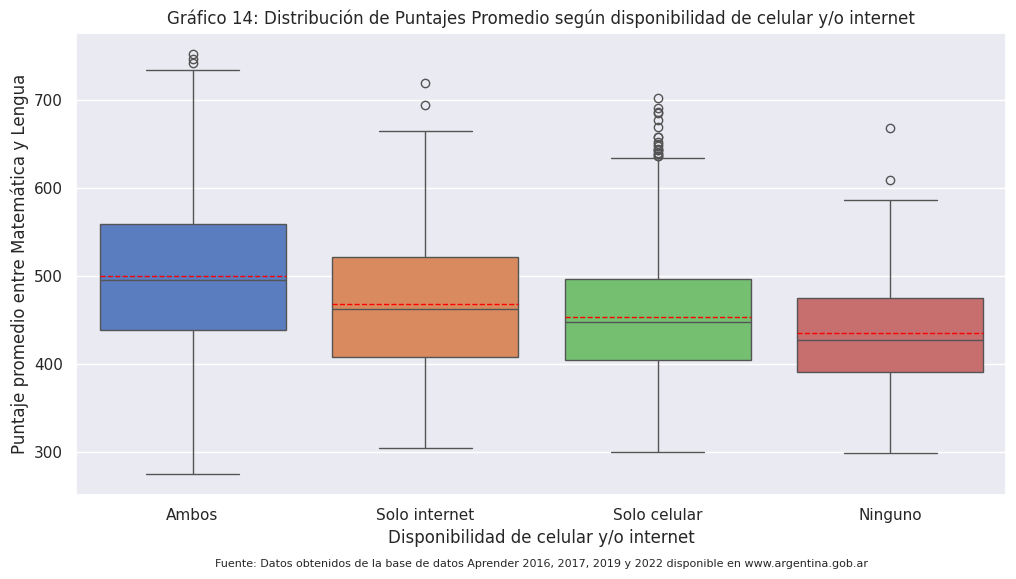

In [35]:
opciones = ['Ambos', 'Solo internet', 'Solo celular', 'Ninguno']
datos_internet['estado_internet'] = pd.Categorical(datos_internet['estado_internet'], categories=opciones, ordered=True)

plt.figure(figsize=(12, 6))
sns.boxplot(x='estado_internet', y='prom_puntaje', data = datos_internet, hue='estado_internet', showmeans=True, meanline=True, meanprops={'color': 'red'}, palette='muted')
plt.title('Gráfico 14: Distribución de Puntajes Promedio según disponibilidad de celular y/o internet')
plt.xlabel('Disponibilidad de celular y/o internet')
plt.ylabel('Puntaje promedio entre Matemática y Lengua')
plt.text(0.5, -0.15, 'Fuente: Datos obtenidos de la base de datos Aprender 2016, 2017, 2019 y 2022 disponible en www.argentina.gob.ar', ha='center', va='center', transform=plt.gca().transAxes, fontsize=8)
plt.show()

## 3.8 (Pregunta 4) ¿Cómo afectó la pandemia a las notas de los alumnos?

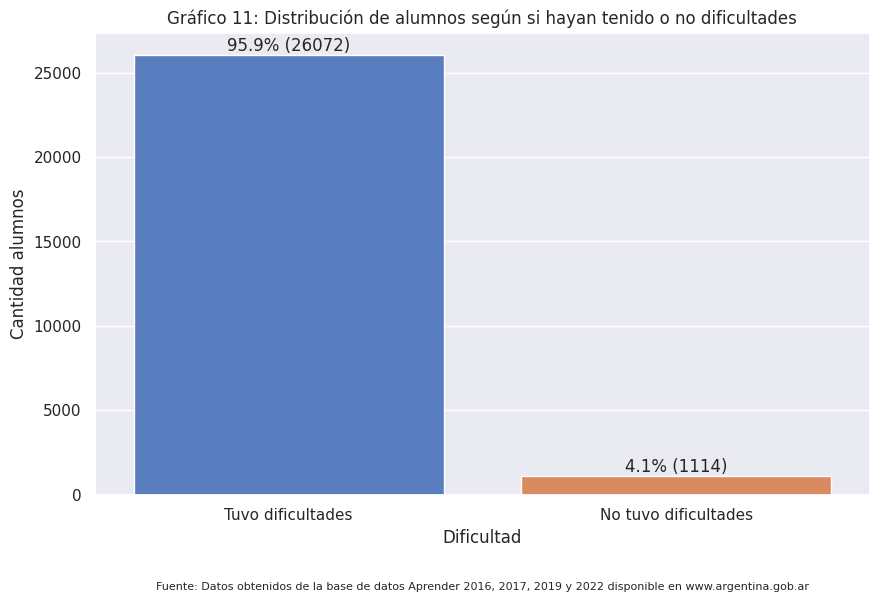

In [36]:
sf_sin_na = datos_santafe.dropna(subset=['mpuntaje','lpuntaje','prom_puntaje','ap29a','ap29b','ap29c','ap29d','ap29e','ap29f','ap29g','ap29h','ap29i','ap29j']).copy()

columnas_pandemia = ['ap29a','ap29b','ap29c','ap29d','ap29e','ap29f','ap29g','ap29h','ap29i','ap29j']

datos_pandemia = sf_sin_na[['mpuntaje','lpuntaje','prom_puntaje','ap29a','ap29b','ap29c','ap29d','ap29e','ap29f','ap29g','ap29h','ap29i','ap29j']].copy()
datos_pandemia['Dificultad'] = datos_pandemia[columnas_pandemia].eq(1).any(axis=1).map({True: "Tuvo dificultades", False: "No tuvo dificultades"})

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=datos_pandemia, x='Dificultad', hue='Dificultad', palette='muted', legend=False)
plt.ylabel('Cantidad alumnos')
plt.title('Gráfico 11: Distribución de alumnos según si hayan tenido o no dificultades')
plt.text(0.5, -0.2, 'Fuente: Datos obtenidos de la base de datos Aprender 2016, 2017, 2019 y 2022 disponible en www.argentina.gob.ar', ha='center', va='center', transform=plt.gca().transAxes, fontsize=8)

# Añadimos los labels
total = len(datos_pandemia)
for container in ax.containers:
    labels = [f'{(v.get_height() / total) * 100:.1f}% ({int(v.get_height())})' for v in container]
    ax.bar_label(container, labels=labels)

plt.show()


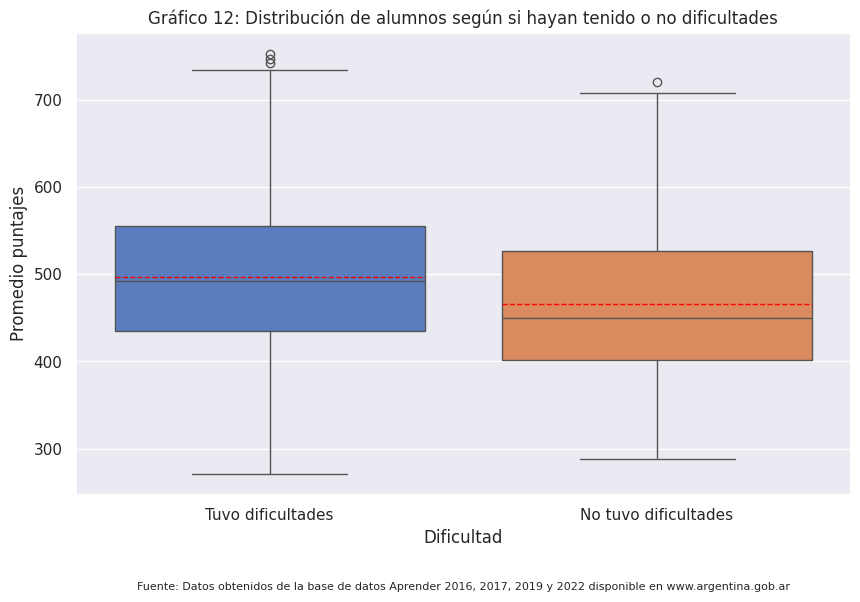

In [37]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=datos_pandemia, x='Dificultad', y='prom_puntaje', hue='Dificultad', palette='muted', showmeans=True, meanline=True, meanprops={'color': 'red'})
plt.ylabel('Promedio puntajes')
plt.title('Gráfico 12: Distribución de alumnos según si hayan tenido o no dificultades')
plt.text(0.5, -0.2, 'Fuente: Datos obtenidos de la base de datos Aprender 2016, 2017, 2019 y 2022 disponible en www.argentina.gob.ar', ha='center', va='center', transform=plt.gca().transAxes, fontsize=8)
plt.show()

In [38]:
datos_pand = datos_pandemia[['prom_puntaje','Dificultad']]
datos_con_dummies = pd.get_dummies(datos_pand)
# Calculamos la matriz de correlación
correlacion = datos_con_dummies.corr()
correlacion

,prom_puntaje,Dificultad_No tuvo dificultades,Dificultad_Tuvo dificultades
prom_puntaje,1.000000,-0.075149,0.075149
Dificultad_No tuvo dificultades,-0.075149,1.000000,-1.000000
Dificultad_Tuvo dificultades,0.075149,-1.000000,1.000000


In [39]:
#2016
!gdown 1k92yMQPrVPbYM3VYvrC1a74C1au9a_T5
#2017
!gdown 1pnBFdxuPOU130ZjwyQXe7MbXEJQcKV5s
#2019
!gdown 13aLkSJcVd6LUQZgN0A1aWJTkt-BXx6MW

Downloading...
From (original): https://drive.google.com/uc?id=1k92yMQPrVPbYM3VYvrC1a74C1au9a_T5
From (redirected): https://drive.google.com/uc?id=1k92yMQPrVPbYM3VYvrC1a74C1au9a_T5&confirm=t&uuid=51516655-7eb5-44a5-8aaa-76fa3b45fbe2
To: /content/Censo Secundaria 5_6 año 2016 USUARIA.csv
100% 196M/196M [00:01<00:00, 150MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1pnBFdxuPOU130ZjwyQXe7MbXEJQcKV5s
From (redirected): https://drive.google.com/uc?id=1pnBFdxuPOU130ZjwyQXe7MbXEJQcKV5s&confirm=t&uuid=afb029cc-23af-4234-b3cf-dcedea31004c
To: /content/Base estudiantes 5-6 año secundaria 2017 USUARIA.csv
100% 144M/144M [00:01<00:00, 121MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=13aLkSJcVd6LUQZgN0A1aWJTkt-BXx6MW
From (redirected): https://drive.google.com/uc?id=13aLkSJcVd6LUQZgN0A1aWJTkt-BXx6MW&confirm=t&uuid=9837fc58-9a15-4aff-b7f7-a02113e70772
To: /content/Base estudiantes 5-6 año secundaria 2019 USUARIA (Censo L y M).csv
100% 249M/249M [00:03<00

In [40]:
raw_datos_csv1 = '/content/Censo Secundaria 5_6 año 2016 USUARIA.csv'
datos2016 = pd.read_csv(raw_datos_csv1, sep=';',decimal=',',na_values=' ')

raw_datos_csv2 = '/content/Base estudiantes 5-6 año secundaria 2017 USUARIA.csv'
datos2017 = pd.read_csv(raw_datos_csv2, sep=';',decimal=',',na_values=' ')

raw_datos_csv3 = '/content/Base estudiantes 5-6 año secundaria 2019 USUARIA (Censo L y M).csv'
datos2019 = pd.read_csv(raw_datos_csv3, sep=';',decimal=',',na_values=' ')

<ipython-input-40-2cca82be5869>:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  datos2016 = pd.read_csv(raw_datos_csv1, sep=';',decimal=',',na_values=' ')


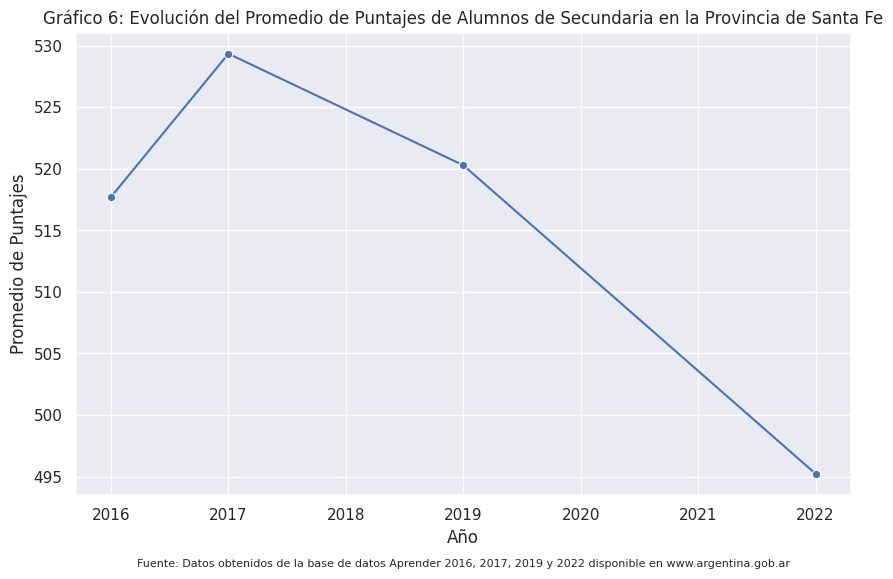

In [41]:
datos2016['provincia'] = datos2016['cod_provincia'].map(provincia_mapping)
datos2016_santafe = datos2016[datos2016['provincia']== 'Santa Fe'].copy()
datos2016_santafe['prom_puntaje'] = (datos2016_santafe['lpuntaje'] + datos2016_santafe['mpuntaje']) / 2

datos2017['provincia'] = datos2017['cod_provincia'].map(provincia_mapping)
datos2017_santafe = datos2017[datos2017['provincia']== 'Santa Fe'].copy()
datos2017_santafe['prom_puntaje'] = (datos2017_santafe['lpuntaje'] + datos2017_santafe['mpuntaje']) / 2

datos2019['provincia'] = datos2019['cod_provincia'].map(provincia_mapping)
datos2019_santafe = datos2019[datos2019['provincia']== 'Santa Fe'].copy()
datos2019_santafe['prom_puntaje'] = (datos2019_santafe['TEL'] + datos2019_santafe['TEM']) / 2

# Calculamos los promedios de los puntajes para cada año
promedio_2016 = datos2016_santafe['prom_puntaje'].mean()
promedio_2017 = datos2017_santafe['prom_puntaje'].mean()
promedio_2019 = datos2019_santafe['prom_puntaje'].mean()
promedio_2022 = datos_santafe['prom_puntaje'].mean()

# DataFrame con los promedios
promedios = pd.DataFrame({
    'año': [2016, 2017, 2019, 2022],
    'promedio_puntaje': [promedio_2016, promedio_2017, promedio_2019, promedio_2022]
})

sns.set(style="darkgrid")
plt.figure(figsize=(10, 6))
sns.lineplot(x='año', y='promedio_puntaje', marker='o', data=promedios)
plt.xlabel('Año')
plt.ylabel('Promedio de Puntajes')
plt.title('Gráfico 6: Evolución del Promedio de Puntajes de Alumnos de Secundaria en la Provincia de Santa Fe')
plt.text(0.5, -0.15, 'Fuente: Datos obtenidos de la base de datos Aprender 2016, 2017, 2019 y 2022 disponible en www.argentina.gob.ar', ha='center', va='center', transform=plt.gca().transAxes, fontsize=8)
plt.grid(True)
plt.show()

